<a href="https://colab.research.google.com/github/palak0626/predictive-analysis/blob/main/sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/Creditcard_data.csv")

In [3]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.shape)
print(df.columns)

(772, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [5]:
print(df['Class'].value_counts())

Class
0    763
1      9
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

In [7]:
ans = df['Class'].value_counts()

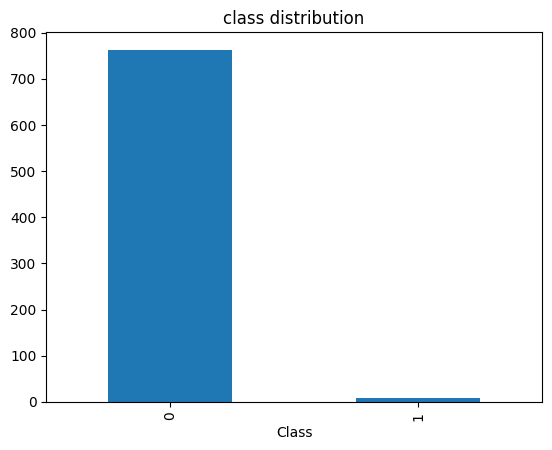

In [8]:
ans.plot(kind = 'bar')
plt.title("class distribution")
plt.show()

# undersampling

In [9]:
from imblearn.under_sampling import RandomUnderSampler

In [10]:
x = df.drop('Class', axis = 1)
y = df['Class']

rus = RandomUnderSampler()
x_rus , y_rus = rus.fit_resample(x,y)

print(y_rus.value_counts())


Class
0    9
1    9
Name: count, dtype: int64


In [17]:
balanced_df = pd.concat([x_rus , y_rus] , axis =1)
print(balanced_df['Class'].value_counts())


Class
0    9
1    9
Name: count, dtype: int64


# simple random sampling

In [18]:
sample1 = balanced_df.sample(frac=0.8, random_state=1)

# stratified sampling

In [19]:
from sklearn.model_selection import train_test_split

sample2, _ = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['Class'],
    random_state=1
)

# systematic sampling

In [20]:
import numpy as np

step = 2
sample3 = balanced_df.iloc[np.arange(0, len(balanced_df), step)]

# cluster sampling

In [21]:
balanced_df['cluster'] = pd.cut(balanced_df['V1'], bins=5, labels=False)

cluster_id = 2
sample4 = balanced_df[balanced_df['cluster'] == cluster_id]

sample4 = sample4.drop('cluster', axis=1)

# bootstrap sampling

In [22]:
from sklearn.utils import resample

sample5 = resample(balanced_df, replace=True, n_samples=len(balanced_df), random_state=1)

In [23]:
samples = [sample1 , sample2 , sample3 , sample4 , sample5]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "M1": LogisticRegression(max_iter = 1000),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(),
    "M4": KNeighborsClassifier(n_neighbors=2),
    "M5": SVC()
}

In [37]:
results = {}

for i, sample in enumerate(samples):


    X_s = sample.drop('Class', axis=1)
    y_s = sample['Class']


    X_train, X_test, y_train, y_test = train_test_split(
        X_s, y_s, test_size=0.2, random_state=42
    )


    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    sampling_name = f"Sampling{i+1}"
    results[sampling_name] = {}


    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)

        results[sampling_name][name] = acc

In [38]:
result_df = pd.DataFrame(results)
print(result_df)

    Sampling1  Sampling2  Sampling3  Sampling4  Sampling5
M1   0.333333   0.333333        0.0        0.0        1.0
M2   0.666667   1.000000        0.0        1.0        1.0
M3   1.000000   0.333333        0.5        1.0        1.0
M4   0.333333   0.333333        0.5        1.0        1.0
M5   0.333333   0.000000        0.5        0.0        1.0
